# Chapter 4: Tracking the CV-LB Gap

**With no shift and no leak, how far does the CV-LB gap move from sampling alone, and can a public sample of a given size reveal a candidate that is truly better by a small amount?**

A competitor sees a gap move and a public score go up or down after a change. Before blaming the feature, you need to know how much movement sampling alone produces and which comparison can separate a real gain from it.

*Constructed data with no shift, leak or selection; a real gap also contains those. The unpaired rule is a naive baseline for contrast, not a recommended practice.*

## The experiment

A constructed binary task with six features, 3,000 training rows and a hidden pool of 60,000 rows from the same generator, so there is no shift. The baseline logistic model uses five features; the candidate adds a sixth that carries a small real signal. The gap is public log loss minus local 5-fold log loss. Public samples of m rows are drawn from the pool, 300 per competition, over 20 independent competitions. The candidate's gain is judged two ways: paired (the standard error of the per-row loss difference) and unpaired (treating the two public scores as independent, each with its own standard error). Detection means the gain exceeds 1.96 standard errors.

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold

from kaggle_companion.activities._common import clean

SEED = 4
REPLICATES = 20          # independent constructed competitions (training set, local CV and large pool of "hidden" rows)
DRAWS = 300              # public samples drawn from the hidden pool in each replicate
N_TRAIN, POOL = 3000, 60000
WEIGHTS = np.array([0.9, -0.7, 0.5, 0.4, -0.3, 0.15])   # the sixth feature carries a small true signal
Z95 = 1.96


def generate(rng, n):
    X = rng.normal(size=(n, 6))
    y = (rng.random(n) < 1 / (1 + np.exp(-(X @ WEIGHTS - 0.2)))).astype(int)
    return X, y


def row_loss(y, p):
    """Log loss of each row; the leaderboard score is the mean of these."""
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))


def one_competition(public_rows, seed):
    rng = np.random.default_rng(seed)
    X, y = generate(rng, N_TRAIN)
    X_hidden, y_hidden = generate(rng, POOL)
    base, cand = slice(0, 5), slice(0, 6)          # baseline: five features; candidate: all six

    # Local CV of the unchanged baseline: 5-fold out-of-fold loss on the training rows.
    oof = np.zeros(N_TRAIN)
    for a, b in KFold(5, shuffle=True, random_state=0).split(X):
        oof[b] = LogisticRegression().fit(X[a][:, base], y[a]).predict_proba(X[b][:, base])[:, 1]
    cv_base = row_loss(y, oof).mean()

    # Per-row loss of both final models on the hidden pool. The same rows are scored by both.
    loss_b = row_loss(y_hidden, LogisticRegression().fit(X[:, base], y).predict_proba(X_hidden[:, base])[:, 1])
    loss_c = row_loss(y_hidden, LogisticRegression().fit(X[:, cand], y).predict_proba(X_hidden[:, cand])[:, 1])

    # Many public samples of `public_rows` hidden rows each.
    idx = rng.integers(0, POOL, (DRAWS, public_rows))
    B, C = loss_b[idx], loss_c[idx]
    D = B - C                                           # per-row paired difference, positive when the candidate is better
    gain = D.mean(axis=1)
    se_paired = D.std(axis=1, ddof=1) / np.sqrt(public_rows)
    se_unpaired = np.sqrt((B.var(axis=1, ddof=1) + C.var(axis=1, ddof=1)) / public_rows)   # two independent scores
    gap = B.mean(axis=1) - cv_base                      # chapter's gap: public loss minus local loss
    return {"pool_base": loss_b.mean(), "pool_cand": loss_c.mean(), "gap": gap, "gain": gain,
            "worse": (gain < 0).mean(), "paired_hit": (gain / se_paired > Z95).mean(),
            "unpaired_hit": (gain / se_unpaired > Z95).mean(),
            "se_paired": se_paired.mean(), "se_unpaired": se_unpaired.mean()}


def run(public_rows):
    runs = [one_competition(public_rows, SEED * 1000 + i) for i in range(REPLICATES)]
    mean = lambda key: float(np.mean([r[key] for r in runs]))
    pool_base, pool_cand = round(mean("pool_base"), 4), round(mean("pool_cand"), 4)
    return clean({
        "public_rows": public_rows,
        "pool_base": pool_base, "pool_cand": pool_cand, "true_gain": round(pool_base - pool_cand, 4),
        # spread of the gap of an UNCHANGED model: public sampling within a competition, and the development side across them
        "gap_public_sd": float(np.mean([r["gap"].std() for r in runs])),
        "gap_dev_sd": float(np.std([r["gap"].mean() for r in runs])),
        "looks_worse": mean("worse"), "paired_detects": mean("paired_hit"), "unpaired_detects": mean("unpaired_hit"),
        "se_paired": mean("se_paired"), "se_unpaired": mean("se_unpaired"),
        "public_gains": np.concatenate([r["gain"][:25] for r in runs]).tolist(),
        "replicates": REPLICATES, "draws": DRAWS, "training_rows": N_TRAIN, "hidden_rows": POOL,
    })


## Measure it across the control

The control is **rows in the public sample**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch04 import explain

VALUES = [250, 1000, 4000, 16000]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                  250    1000    4000   16000
Gap spread (public sampling)    0.028   0.014   0.007   0.004
Gap spread (development side)   0.010   0.009   0.009   0.009
True gain                      0.0021  0.0021  0.0021  0.0021
Better candidate looks worse      32%     16%      3%      0%
Paired detects                     8%     19%     55%     94%
Unpaired detects                   0%      0%      0%      0%


## Look at it

The figure shows the default setting, rows in the public sample = 1000.

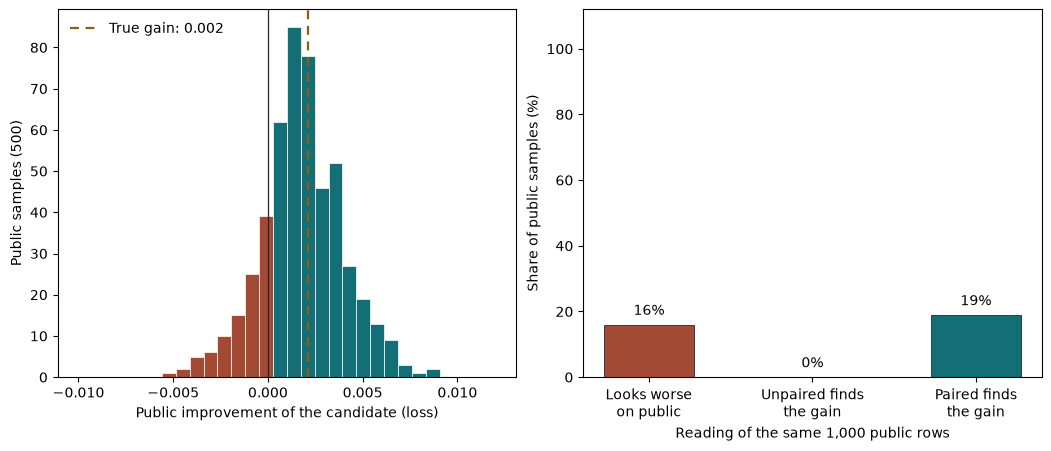

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch04 import draw, NCOLS, HEIGHT

DEFAULT = 1000
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 1,000 public rows an unchanged model's gap wanders by a standard deviation of 0.014 from public sampling alone, and by 0.009 from the development side, against a true gain of 0.5496 - 0.5475 = 0.0021. The truly better candidate looks worse on 16% of public samples. Read as two independent scores the gain is found in 0% of samples (standard error 0.020); read as a paired difference it is found in 19% (standard error 0.002).

- True gain: 0.5496 - 0.5475 = 0.0021 (baseline minus candidate loss on 60,000 hidden rows).
- Sampling-only gap spread, public side: 0.014; development side: 0.009.
- Share of public samples where the better candidate looks worse: 16%.
- Share detected at 1.96 standard errors: paired 19%, unpaired 0%.

## Apply this to your competition

- Expect a gap to move by sampling alone: estimate that spread from the size of the public sample before reading a change as shift or leakage.
- Compare baseline and candidate row by row on the same rows, and report the paired difference with its standard error.
- If the paired interval includes zero, the evidence cannot separate the candidate from the baseline; collect more rows or blocks, or stop.
- Never reject or accept a feature because the public score moved by less than the sampling spread; log the paired result instead.

Book location: Chapter 4, The Three Gap Patterns.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)